# Raw Firing Rate Map — First Principles

Before trusting any binned / thresholded / occupancy-normalized rate map, look at the **rawest possible view**: for every single timestep, plot the agent's `(x, y)` position colored by that neuron's raw activation value at that instant.

No binning. No smoothing. No thresholding. No occupancy normalization. If a neuron genuinely has a place field, it should be visible by eye as a spatial cluster of hot-colored points — no statistics required. This is the ground truth we validate any derived (binned/smoothed) rate map against later.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [12]:
data_file = '/Users/sindhuramrutha/documents/project_ventures/cns_lab/hpc_liza/2d_hippocampal_cells/2D-traj-results-training.pkl'
with open(data_file, 'rb') as f:
    data = pickle.load(f)

In [13]:
data.keys()

TRAJ_IDX = 0     # data['prediction'] / data[LAYER_NAME] hold 500 separate trajectories — pick one
LAYER_NAME = 'z3'

positions = data['prediction'][TRAJ_IDX]      # (T, 2)
activations = data[LAYER_NAME][TRAJ_IDX]      # (T, neurons)

In [ ]:
def get_input_data(activation_path, trajectory_path):
    with open(trajectory_path, 'rb') as f:
        data_pos = pickle.load(f)

    with open(activation_path, 'rb') as f:
        activations = pickle.load(f)

    x = np.asarray(data_pos['x'])
    y = np.asarray(data_pos['y'])
    positions = np.column_stack((x, y))
    return positions, activations

# Get input data (same source as PlaceCell_Identification_org.ipynb)
activation_path = 'z1_real_activations.pkl'
trajectory_path = 'trajectory_data.pkl'

positions, activations = get_input_data(activation_path, trajectory_path)

In [14]:

print('positions:', positions.shape)      # (T, 2)
print('activations:', activations.shape)  # (T, neurons)

positions: (500, 2)
activations: (500, 100)


### Step 0 — Where did the agent actually go?

Before overlaying any activation color, look at raw trajectory coverage. Any spatial pattern we see later in a firing map has to be interpreted against this — a neuron can only look spatially selective in places the agent actually visited.

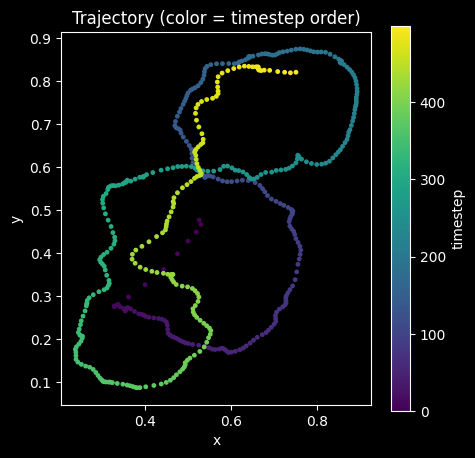

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(positions[:, 0], positions[:, 1], c=np.arange(len(positions)), cmap='viridis', s=6)
ax.set_title('Trajectory (color = timestep order)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.colorbar(sc, ax=ax, label='timestep')
plt.show()

### Step 1 — Raw activation-position map for a single neuron

`activations[layer, :, neuron]` is already timestep-aligned with `positions`, so we can color each visited point directly by that neuron's instantaneous activation — no binning needed.

One plotting detail that matters: scatter draws points in array order, so if low-activation points happen to be plotted after high-activation ones, they can visually bury a real hotspot. We sort by activation ascending so the highest (most interesting) values are drawn last, on top.

In [16]:
def plot_raw_activation_map(positions, activation_trace, title="", ax=None, cmap='jet', point_size=10):
    '''
    Literal scatter of every (x, y) sample, colored by raw activation at that timestep.
    No binning, smoothing, thresholding, or occupancy normalization.
    '''
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))

    order = np.argsort(activation_trace)  # low -> high, so high values draw last (on top)
    sc = ax.scatter(positions[order, 0], positions[order, 1],
                     c=activation_trace[order], cmap=cmap, s=point_size, edgecolors='none')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal')
    return sc

/Users/sindhuramrutha/miniconda3/envs/theta_venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/sindhuramrutha/miniconda3/envs/theta_venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py:4733: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


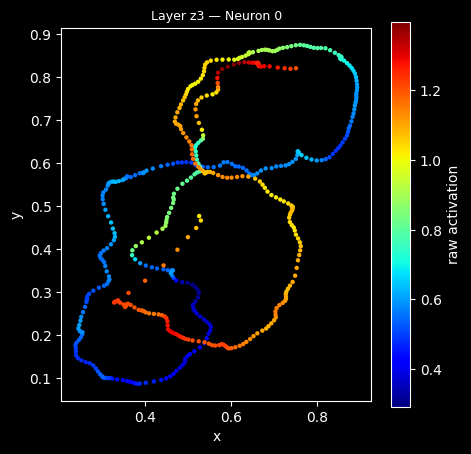

In [17]:
neuron_idx = 0

trace = activations[:, neuron_idx]

fig, ax = plt.subplots(figsize=(5, 5))
sc = plot_raw_activation_map(positions, trace, title=f'Layer {LAYER_NAME} — Neuron {neuron_idx}', ax=ax)
plt.colorbar(sc, ax=ax, label='raw activation')
plt.show()

### Step 2 — All neurons in a layer, side by side

Eyeball every neuron at once. Spatially-tuned neurons should show an obvious localized hot region; non-spatial neurons should look like a uniform / speckled mix of colors across the whole arena.

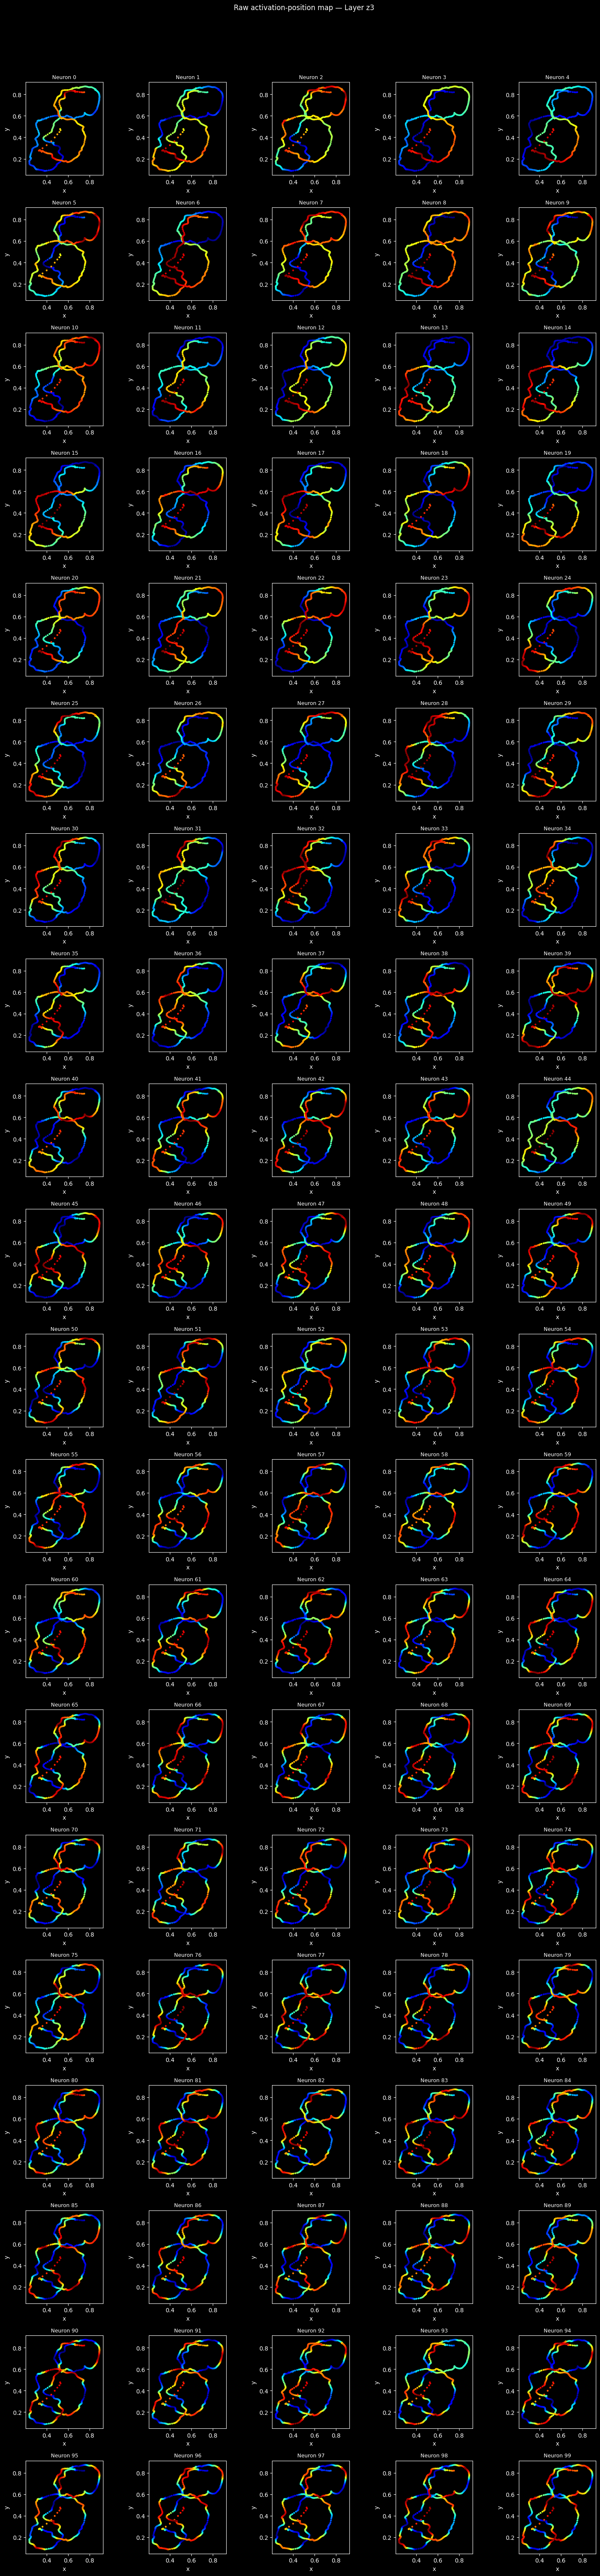

In [18]:
n_neurons = activations.shape[1]
ncols = 5
nrows = int(np.ceil(n_neurons / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.ravel()

for n in range(n_neurons):
    trace = activations[:, n]
    plot_raw_activation_map(positions, trace, title=f'Neuron {n}', ax=axes[n])

for ax in axes[n_neurons:]:
    ax.axis('off')

fig.suptitle(f'Raw activation-position map — Layer {LAYER_NAME}', y=1.02)
plt.tight_layout()
plt.show()

### Step 3 — Switch layer

Reuse the same grid to inspect any other layer by changing `LAYER_NAME` (must be one of `data.keys()`, e.g. `d1`, `z1`, `d2`, `z2`, `d3`, `z3`, `d4`). Each layer array is reloaded and re-sliced by `TRAJ_IDX` since `data[layer]` holds all 500 trajectories.

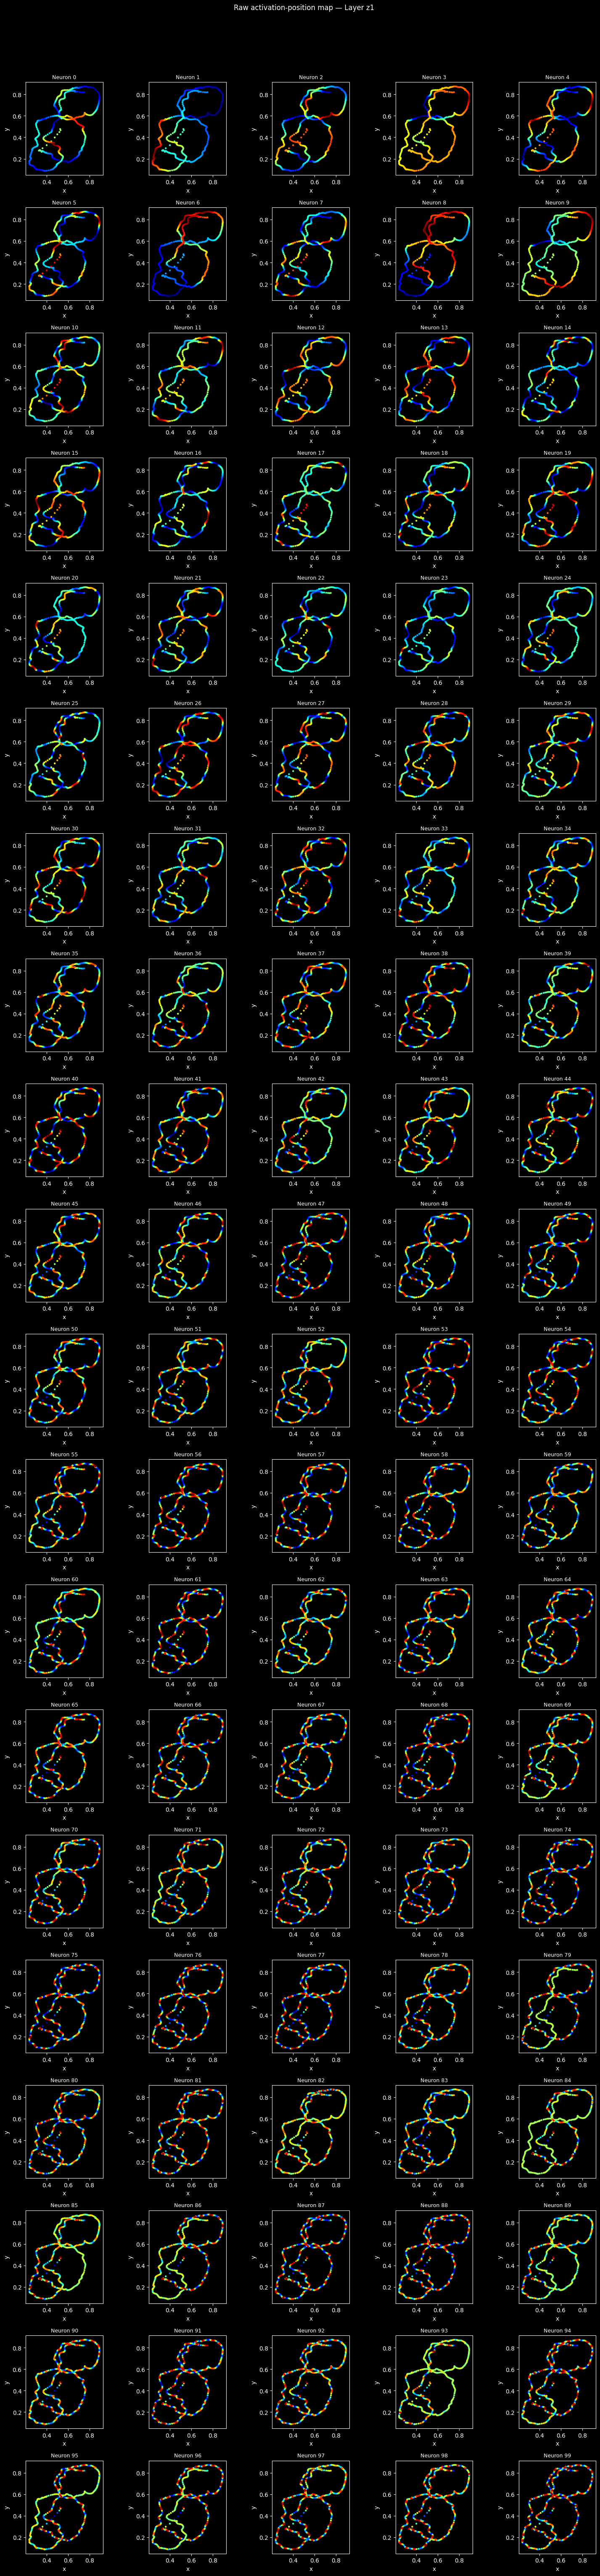

In [19]:
LAYER_NAME = 'z1'  # change me — any key in data.keys()

activations = data[LAYER_NAME][TRAJ_IDX]
n_neurons = activations.shape[1]
nrows = int(np.ceil(n_neurons / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
axes = axes.ravel()

for n in range(n_neurons):
    trace = activations[:, n]
    plot_raw_activation_map(positions, trace, title=f'Neuron {n}', ax=axes[n])

for ax in axes[n_neurons:]:
    ax.axis('off')

fig.suptitle(f'Raw activation-position map — Layer {LAYER_NAME}', y=1.02)
plt.tight_layout()
plt.show()

---
**Next step (not yet done here):** once we've visually confirmed which neurons look genuinely spatially tuned in this raw view, we build a *derived* firing rate map (binned + occupancy-normalized) and check that it reproduces the same hotspots seen here — rather than trusting the derived map on its own, as the original pipeline did.